<a href="https://colab.research.google.com/github/TheHashiramaSenju/AnimalDetectionDrone/blob/senju/Linear_Regression_HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#***House Price Prediction using Linear Regression***



---



# *Imporing required modules and libraries*

In [16]:
#importing the required modules and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

# *Load the California housing dataset*

In [17]:
# Load the California housing dataset
housing = fetch_california_housing()
dataset = pd.DataFrame(housing.data, columns=housing.feature_names)
dataset['Price'] = housing.target

# *Data preprocessing*

In [18]:
# Data preprocessing
dataset.fillna(dataset.mean(), inplace=True)

#*Data Visualization*

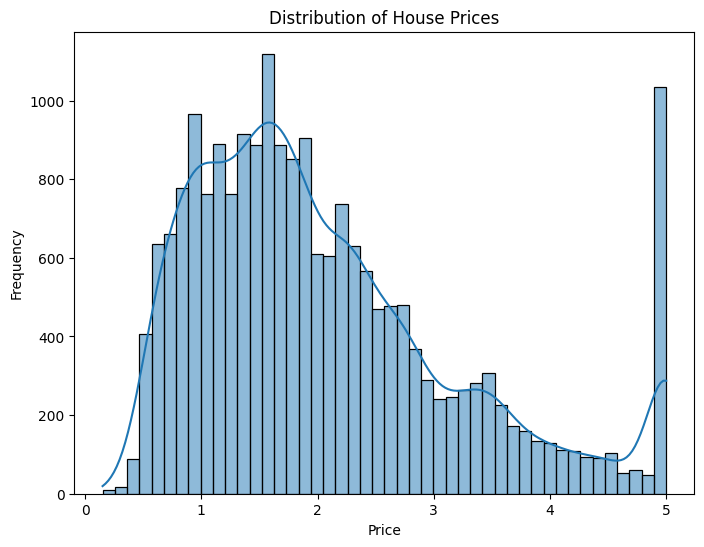

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of the target variable (Price)
plt.figure(figsize=(8, 6))
sns.histplot(dataset['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

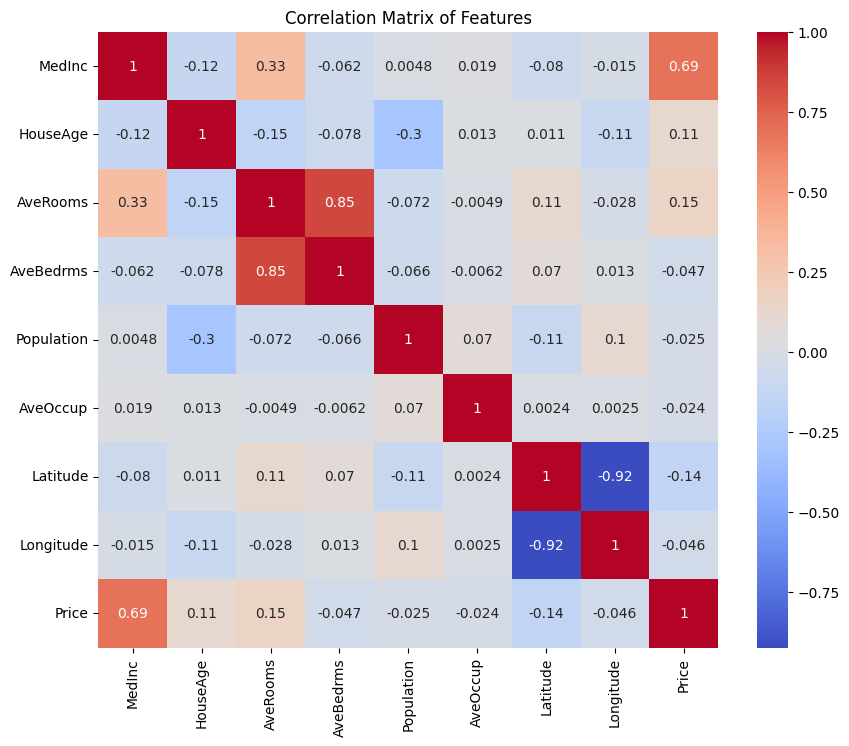

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = dataset.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

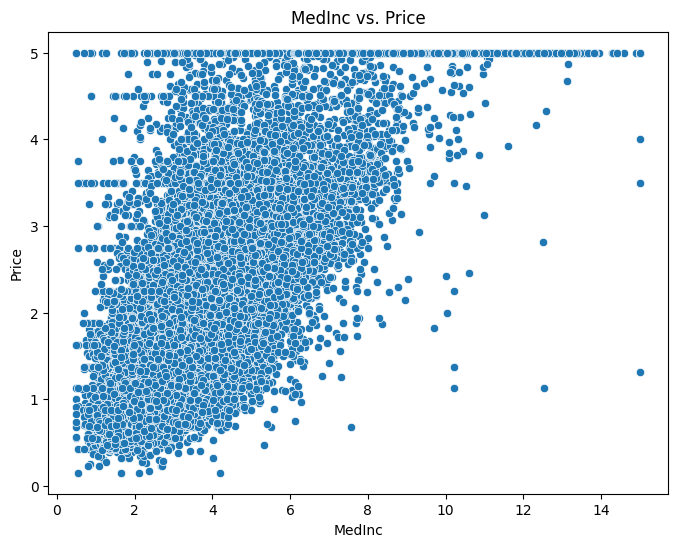

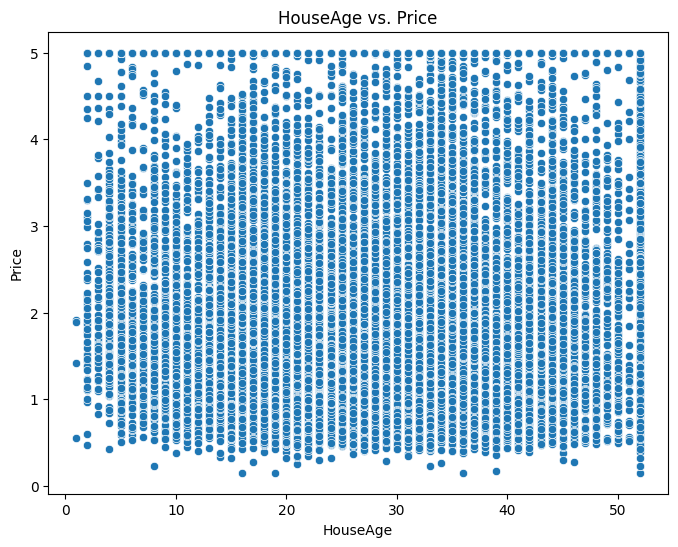

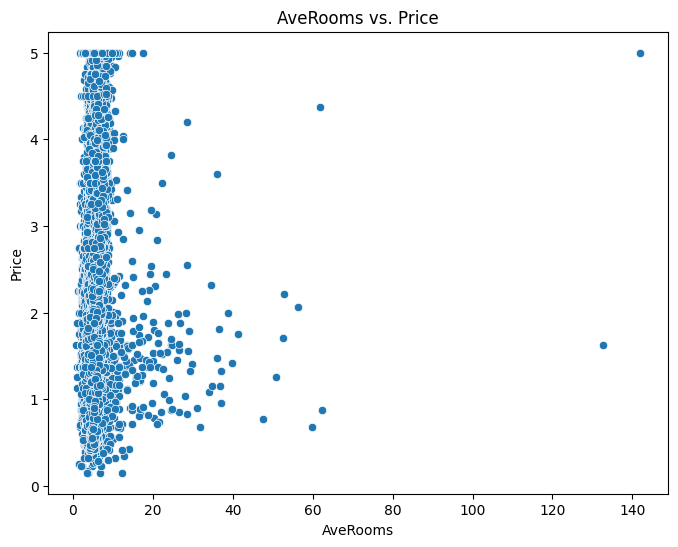

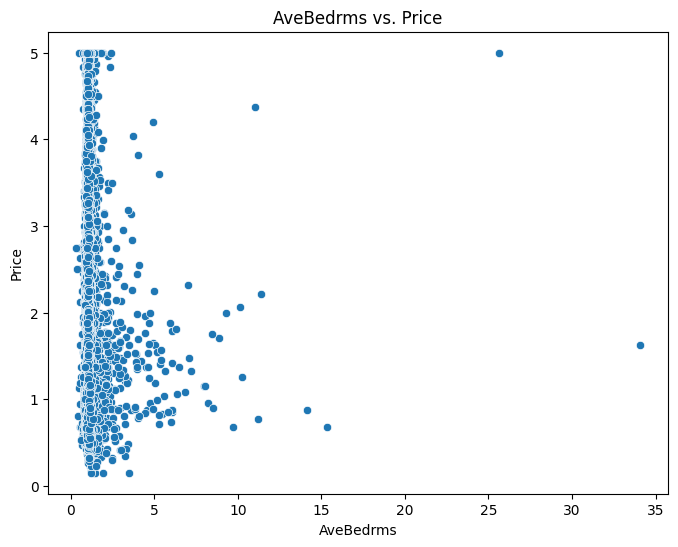

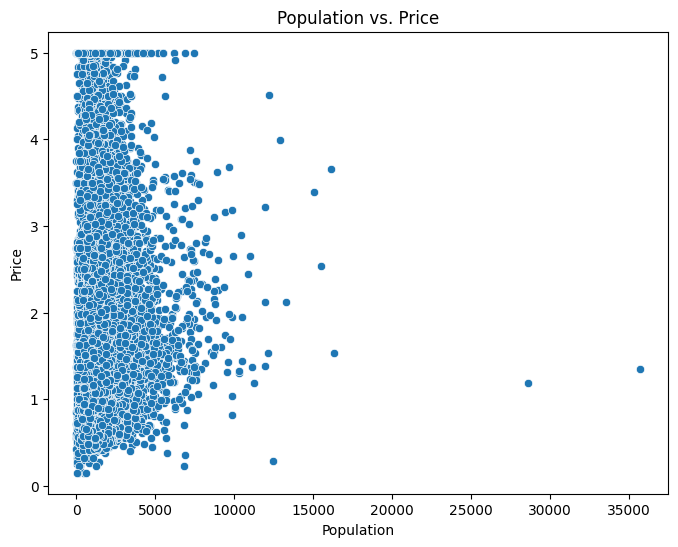

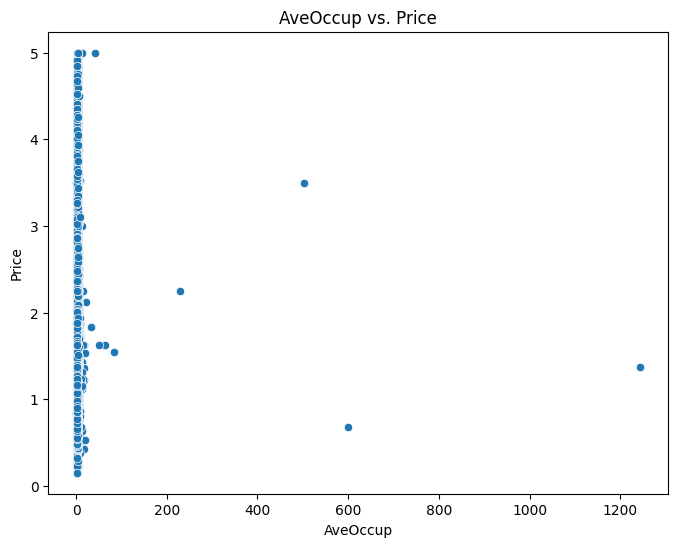

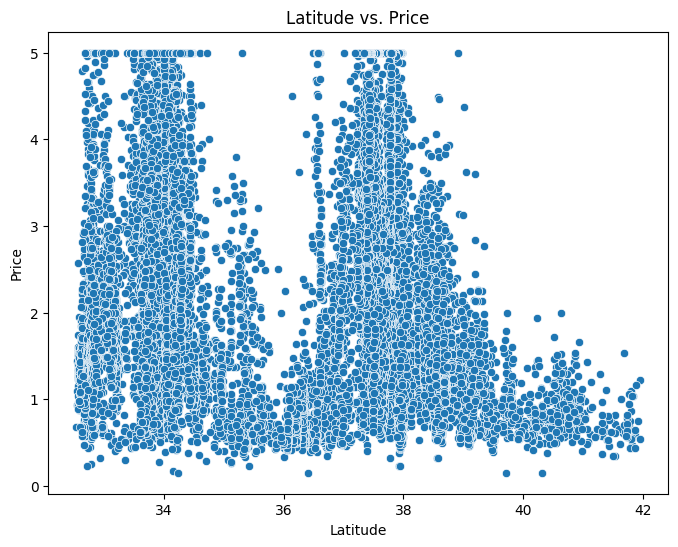

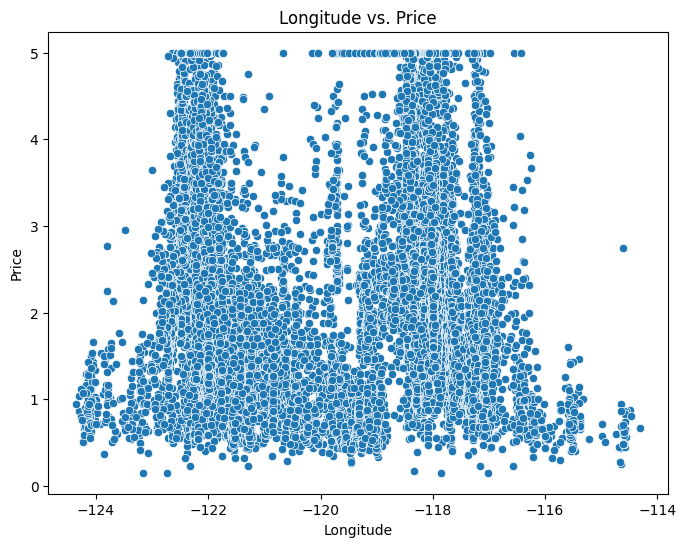

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plots of features vs. Price
for feature in housing.feature_names:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=dataset[feature], y=dataset['Price'])
    plt.title(f'{feature} vs. Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.show()

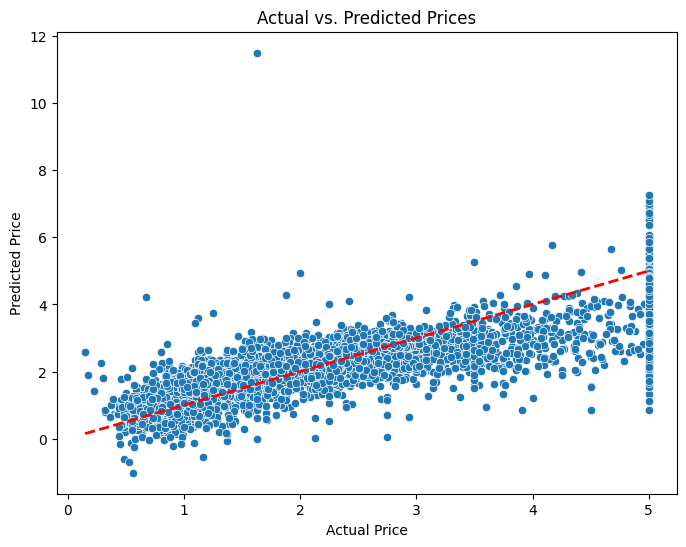

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Actual vs. Predicted Prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

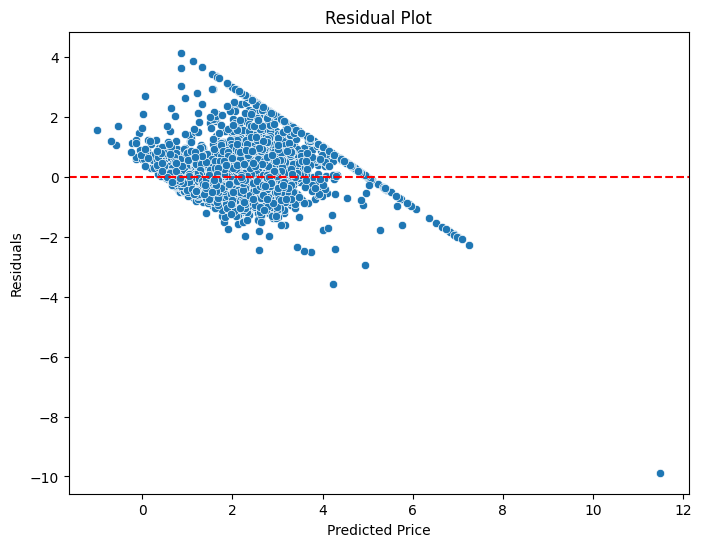

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()

# *Split data*

In [24]:
# Split data
X = dataset.drop('Price', axis=1)
y = dataset['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# *Feature scaling*

In [25]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# *Model training*

In [26]:
# Model training
regression = LinearRegression()
regression.fit(X_train, y_train)


LinearRegression()

# *Model prediction*

In [27]:
# Model prediction
y_pred = regression.predict(X_test)


# *Model evaluation*

In [28]:
# Model evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Squared Error (MSE): 0.56
Mean Absolute Error (MAE): 0.53
R-squared (R2): 0.58
Root Mean Squared Error (RMSE): 0.75


# *Save the trained model*

In [29]:
# Save the trained model
pickle.dump(regression, open('reg_model.pkl', 'wb'))

# *Load the saved model*

In [30]:
# Load the saved model
with open('reg_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)


# *Scaling new data for prediction*

In [31]:
# Scaling new data for prediction
new_data_point = [[0.1, 10.0, 5.0, 1.0, 1000.0, 200.0, 300.0, 10.0]]  # Example values
new_data_scaled = scaler.transform(new_data_point)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# *Make prediction using loaded model*

In [32]:
# Make prediction using loaded model
predicted_price = loaded_model.predict(new_data_scaled)
print("Predicted Price:", predicted_price[0]) # Assuming a single data point for now

Predicted Price: -167.6967593914199
